## Exercises

All exercises in this section use the World Bank Indicators API (see @sec-loading-online). The following helper code fetches population data for a list of countries over a range of years. You may reuse and adapt it.

Gardening: 4 Personen
Tennis: 8 Personen
Yoga: 4 Personen
Swimming: 7 Personen


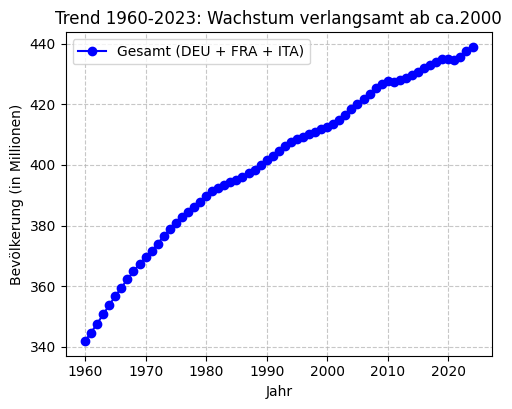

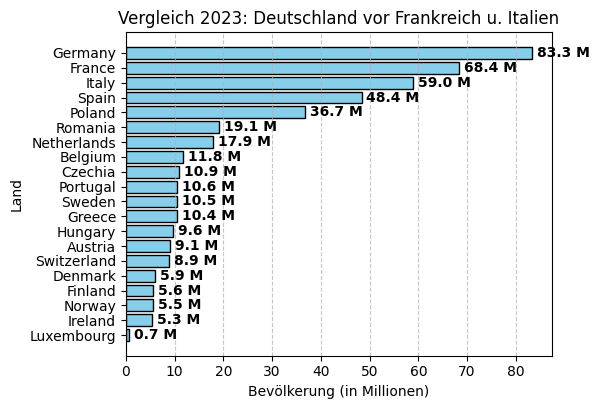

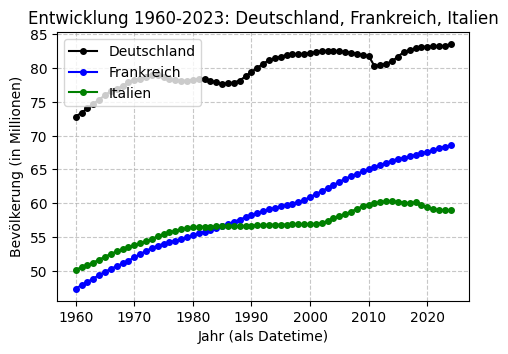

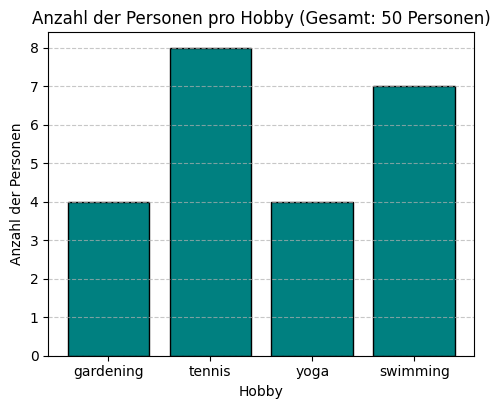

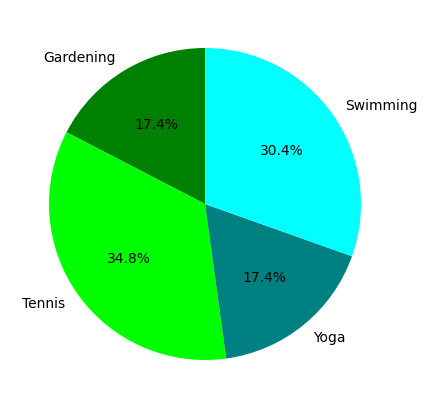

In [12]:
# 08-Matplotlib-exercice_1-bis-4.py 17-06-26
#import matplotlib.pyplot 
#matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import pandas as pd
#--------------------------------------------------------------------------
# 1. Vorhandene CSV-Daten offline einlesen
#--------------------------------------------------------------------------
df = pd.read_csv("20Laender10Indikatoren.csv")
#--------------------------------------------------------------------------
# Gruppe nach 'year' u. Summe nach Bevölkerung DEU + FRA + ITA
df_total = df.groupby("year")["population"].sum().reset_index()
df_2023 = df[df["year"] == 2023].copy()
df_2023_sorted = df_2023.sort_values(by="population", ascending=True)
#--------------------------------------------------------------------------
# 3. Diagramme platzieren
plt.rcParams['toolbar'] = 'None'
#--------------------------------------------------------------------------
# 5. Diagramme platzieren und Tortendiagramm Fig 5 erstellen
#--------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(5.5, 4.20))
#--------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(5.5, 4.20))
#--------------------------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(5.5, 4.20))
plt.subplots_adjust(left=0.20, bottom=0.24, right=0.95)
#--------------------------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(5.5, 4.20))
#--------------------------------------------------------------------------
fig5, ax5 = plt.subplots(figsize=(5.5, 4.20))
#--------------------------------------------------------------------------
# 4. Zeichnen und Beschriften Fig 1
#--------------------------------------------------------------------------
ax1.plot(
    df_total["year"],
    df_total["population"] / 1e6,  # Umr. in Millionen (kleinere Gesamtsumme)
    marker="o",
    linestyle="-",
    color="b",
    label="Gesamt (DEU + FRA + ITA)",)
ax1.set_title("Trend 1960-2023: Wachstum verlangsamt ab ca.2000")
ax1.set_xlabel("Jahr")
ax1.set_ylabel("Bevölkerung (in Millionen)")
ax1.grid(True, linestyle="--", alpha=0.7)
ax1.legend(loc='upper left')
#--------------------------------------------------------------------------
# 5. Zeichnen und Beschriften Fig 2
#--------------------------------------------------------------------------
ax2.barh(
    df_2023_sorted["country"],
    df_2023_sorted["population"] / 1e6,
    color="skyblue",
    edgecolor="black",)
ax2.set_title("Vergleich 2023: Deutschland vor Frankreich u. Italien"
)
ax2.set_xlabel("Bevölkerung (in Millionen)")
ax2.set_ylabel("Land")
ax2.grid(axis="x", linestyle="--", alpha=0.7)  # Gitterlinien nur für die X-Achse
for index, value in enumerate(df_2023_sorted["population"] / 1e6):
    ax2.text(value + 1, index, f"{value:.1f} M", va="center", fontweight="bold")
#--------------------------------------------------------------------------
# 6. Zeichnen und Beschriften Fig 3
#--------------------------------------------------------------------------
df["year_dt"] = pd.to_datetime(df["year"], format="%Y")
laender_daten = [
    {"iso3": "DEU", "color": "black", "label": "Deutschland"},
    {"iso3": "FRA", "color": "blue", "label": "Frankreich"},
    {"iso3": "ITA", "color": "green", "label": "Italien"},
]
for land in laender_daten:
    # Filtern nach ISO3 und Sortieren nach Datum
    df_land = df[df["iso3"] == land["iso3"]].sort_values("year_dt")
    # Linie zur Achse hinzufügen
    ax3.plot(
        df_land["year_dt"],
        df_land["population"] / 1e6,  # Umrechnung in Millionen
        marker="o",
        markersize=4,
        linestyle="-",
        color=land["color"],
        label=land["label"],
    )
fig3.canvas.manager.set_window_title("Figur 3 - Ländervergleich")
ax3.set_title("Entwicklung 1960-2023: Deutschland, Frankreich, Italien")
ax3.set_xlabel("Jahr (als Datetime)")
ax3.set_ylabel("Bevölkerung (in Millionen)")
ax3.grid(True, linestyle="--", alpha=0.7)
ax3.legend(loc="upper left")
#--------------------------------------------------------------------------
# 6. Zeichnen und Beschriften Fig 4 und 5
#--------------------------------------------------------------------------
# 1. Neue CSV-Daten offline einlesen
df_hobbies = pd.read_csv("person.csv")
gesuchte_hobbies = ["gardening", "tennis", "yoga", "swimming"]
hobby_zaehlung = {}
for hobby in gesuchte_hobbies:
    # Zählt, wie oft das Wort im Feld 'hobbies' vorkommt
    anzahl = df_hobbies["hobbies"].str.contains(hobby, case=False, na=False).sum()
    hobby_zaehlung[hobby] = anzahl
# 4. Ergebnisse zur Kontrolle in der Konsole ausgeben
for hobby, anzahl in hobby_zaehlung.items():
    print(f"{hobby.capitalize()}: {anzahl} Personen")
#--------------------------------------------------------------------------

ax4.bar(hobby_zaehlung.keys(), hobby_zaehlung.values(), color="teal", edgecolor="black")

ax5.pie(hobby_zaehlung.values(),
       labels=[h.capitalize() for h in hobby_zaehlung.keys()],
       autopct="%1.1f%%",  # Prozent mit einer Nachkommastelle
       startangle=90,  # erstes Stück oben
       colors=["green","lime","teal","aqua"],  )

# Beschriftungen
ax4.set_title("Anzahl der Personen pro Hobby (Gesamt: 50 Personen)")
ax4.set_xlabel("Hobby")
ax4.set_ylabel("Anzahl der Personen")
ax4.grid(axis="y", linestyle="--", alpha=0.7)
#--------------------------------------------------------------------------
# 8. Diagramme ausgeben
#--------------------------------------------------------------------------
plt.tight_layout()
plt.show()




**Exercise 5**
Generate four groups of random data: `rng.normal(loc=m, scale=s, size=50)` with `(m, s)` = (5, 1), (6, 2), (5.5, 0.5), (7, 1.5). Display them as a **box plot**. Which group has the largest spread? Are there outliers?

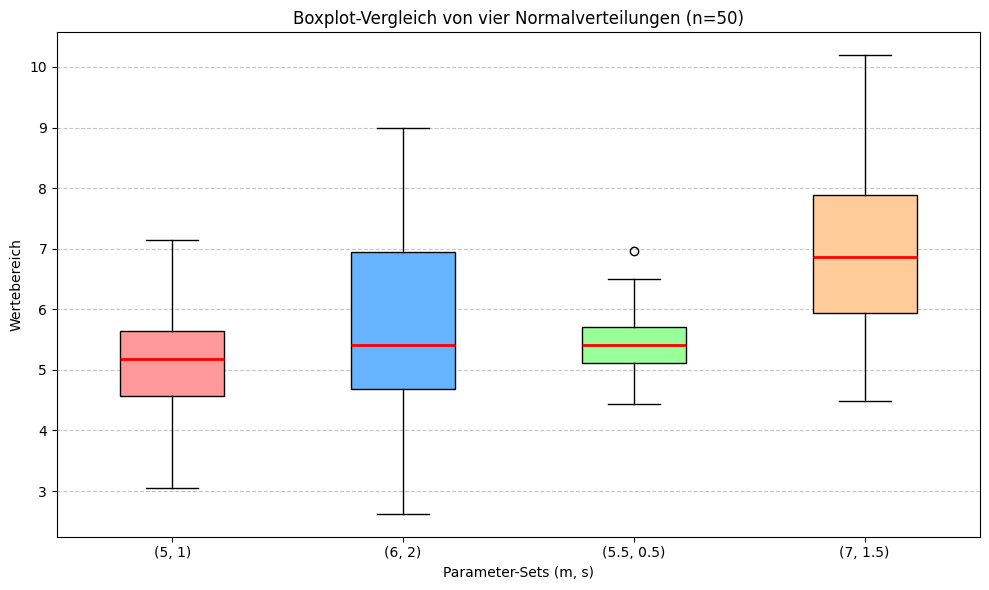

In [9]:
# 08-Matplotlib-exercice_05-1.py 17-06-26
import matplotlib.pyplot as plt
import numpy as np

# 1. Random Number Generator (RNG) initialisieren
rng = np.random.default_rng(seed=42)  # Seed sorgt für exakt gleiche Werte bei jedem Versuch

# 2. Die vier Datensätze laut Vorgabe generieren (jeweils 50 Werte)
data1 = rng.normal(loc=5, scale=1, size=50)
data2 = rng.normal(loc=6, scale=2, size=50)
data3 = rng.normal(loc=5.5, scale=0.5, size=50)
data4 = rng.normal(loc=7, scale=1.5, size=50)

# Alle Datensätze in eine Liste packen
all_data = [data1, data2, data3, data4]

# 3. Figur und Achsen erstellen
fig6, ax6 = plt.subplots(figsize=(10, 6))

# 4. Boxplot erstellen
# patch_artist=True erlaubt es, die Boxen einzufärben
bp = ax6.boxplot(
    all_data,
    patch_artist=True,
    tick_labels=["(5, 1)", "(6, 2)", "(5.5, 0.5)", "(7, 1.5)"],
)

# 5. Styling: Boxen farblich gestalten
farben = ["#ff9999", "#66b3ff", "#99ff99", "#ffcc99"]
for patch, farbe in zip(bp["boxes"], farben):
    patch.set_facecolor(farbe)

# Mediane (die Linien in den Boxen) gut sichtbar machen
for median in bp["medians"]:
    median.set(color="red", linewidth=2)

# 6. Beschriftungen und Titel
fig6.canvas.manager.set_window_title("Figur 5 - Boxplot Analyse")
ax6.set_title("Boxplot-Vergleich von vier Normalverteilungen (n=50)")
ax6.set_xlabel("Parameter-Sets (m, s)")
ax6.set_ylabel("Wertebereich")
ax6.grid(axis="y", linestyle="--", alpha=0.7)

# 7. Diagramm anzeigen
plt.tight_layout()
plt.show()


**Exercise 6**
Generate 500 samples from a normal distribution with mean 170 and standard deviation 10 (think: heights in cm). Plot a **histogram** with 25 bins and `density=True`. Overlay the theoretical density curve using `np.linspace` and `stats.norm.pdf` (you may import `from scipy import stats`). Experiment with `rwidth=0.9` and `alpha=0.7`.

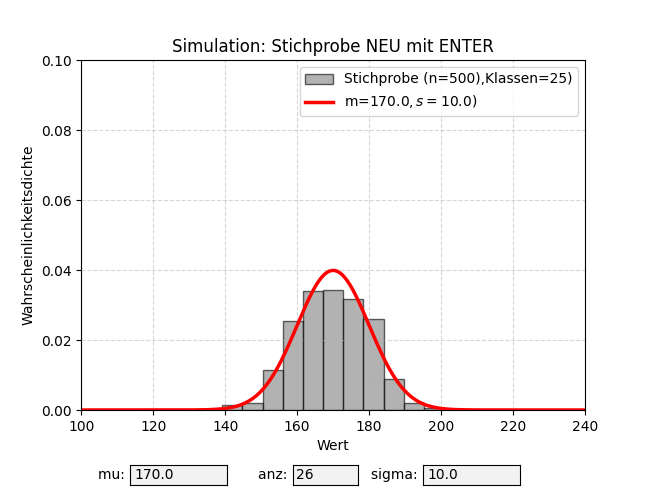

In [6]:
# 08-Matplotlib-exercice_06-8.py 17-06-26
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.widgets import TextBox
from scipy import stats
# plt.rcParams["toolbar"] = "None" # Matplotlib-Toolbar ausschalten
ewmu = 170.0    # Globale Variable mu    (Default)
sigm = 10.0     # Globale Variable sigma (Default)
klas = 26       # Globale Variable klas  (Default)
trigger = False # Globale Variable DRAW-Überwachung
# Zufallsgenerator GLOBAL liefert dann bei jedem Aufruf neue Daten.
rng = np.random.default_rng()  # PCG64-Algorithmus ohne (seed=..)
fig1, ax1 = plt.subplots(figsize=(6.5, 5.0)) # Figur mit Hauptachse 
plt.subplots_adjust(bottom=0.18) # Platz für Eingabefelder frei halten
# ------------------------------------------------------------------------------
#          Zeichen-Funktion (Muss VOR den Textboxen definiert sein)
# ------------------------------------------------------------------------------
def neu_zeichnen(mu, anz, sigma):
  global trigger
  if trigger: return  # Kein ENTER-Interrupt solange gezeichnet wird ...
  try:
    trigger = True # Startschuss zum Zeichnen (Mutex/Debounce)
    ax1.clear()                                      # Grafik löschen
    daten  = rng.normal(loc=mu,scale=sigma,size=500) # NÄCHSTE 500'er Probe         
    balken = np.linspace(100, 240, anz)   # Balkenbreite konstant ca. 140/anz
    # Histogramm zeichnen mit konstant breiten Balken als starre Klassen-Breite 
    ax1.hist(daten,bins=balken,density=True,alpha=0.6,color="grey",edgecolor="black",
        label=f"Stichprobe (n=500),Klassen={anz - 1})")
    # Gauss-Verteilung zum Vergleich
    x = np.linspace(100, 240, 200)
    y = stats.norm.pdf(x, loc=mu, scale=sigma) 
    ax1.plot(x,y,color="red",linewidth=2.5,label=f"m={mu}$,s={sigma}$)",)  
    ax1.set_xlim(100, 240) # x-Achsenbereich konstant
    ax1.set_ylim(0, 0.10)  # y-Achsenbereich konstant
    # Beschriftungen nach Löschen wiederherstellen
    ax1.set_title("Simulation: Stichprobe NEU mit ENTER")
    ax1.set_xlabel("Wert")
    ax1.set_ylabel("Wahrscheinlichkeitsdichte")
    ax1.grid(True, linestyle="--", alpha=0.5)
    ax1.legend(loc="upper right")
    # Neuzeichnen des Fensters
    fig1.canvas.draw_idle()
  finally:
    trigger = False  # ENTER-Interrupts werden wieder berücksichtigt ...
# ------------------------------------------------------------------------------
#           Textbox-Events und exakte Deklaration
# ------------------------------------------------------------------------------
def on_submit_ewmu(text_input):
    global ewmu, sigm, klas
    try:
        ewmu = float(text_input)
        neu_zeichnen(ewmu, klas, sigm)
    except ValueError: return
def on_submit_klas(text_input):
    global ewmu, sigm, klas
    try:
        klas = int(text_input)
        neu_zeichnen(ewmu, klas, sigm)
    except ValueError: return
def on_submit_sigm(text_input):
    global ewmu, sigm, klas
    try:
        sigm = float(text_input)        
        if sigm <= 0:
            sigm = 1.0  # Fallback (Sigma nicht 0 oder negativ)
            text_box_sigm.set_val("1.0")
        neu_zeichnen(ewmu, klas, sigm)
    except ValueError: return
# ------------------------------------------------------------------------------
# Verankerung der Textfelder im Fenster
ax_box_ewmu = plt.axes([0.20, 0.03, 0.15, 0.04])
ax_box_klas = plt.axes([0.45, 0.03, 0.10, 0.04])
ax_box_sigm = plt.axes([0.65, 0.03, 0.15, 0.04])
# Textbox-Objekte erstellen (im globalen Namensraum!)
text_box_ewmu = TextBox(ax_box_ewmu, "mu: ", initial=str(ewmu))
text_box_klas = TextBox(ax_box_klas, "anz: ", initial=str(klas))
text_box_sigm = TextBox(ax_box_sigm, "sigma: ", initial=str(sigm))
# ENTER-Event überwachen
text_box_ewmu.on_submit(on_submit_ewmu)
text_box_klas.on_submit(on_submit_klas)
text_box_sigm.on_submit(on_submit_sigm)
# ------------------------------------------------------------------------------
#           Anstossen der DRAW_idle()-Schleife
# ------------------------------------------------------------------------------
neu_zeichnen(ewmu, klas, sigm)
plt.show() # Fenster anzeigen



**Exercise 7**
Using the data from Exercise 3, compute the population growth per decade (1960s, 1970s, ..., 2010s) for each country. Display the result as a **grouped bar chart** with decades on the x-axis and one bar per country.

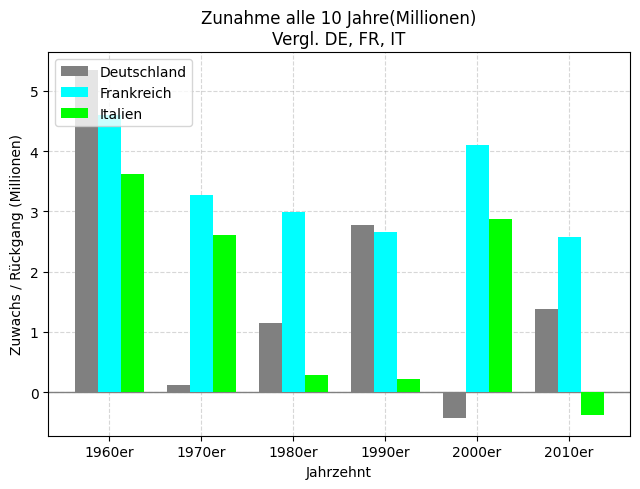

In [3]:
# 08-Matplotlib-exercice_07-1.py 18-06-26
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# plt.rcParams["toolbar"] = "None"

# 1. Daten offline einlesen
df = pd.read_csv("20Laender10Indikatoren.csv")

# 2. Jahrzente in 10er-Schritten (1960, 1970, ..., 2020)
jahrzehnt = [1960, 1970, 1980, 1990, 2000, 2010, 2020]
df_filtered = df[df["year"].isin(jahrzehnt)].copy()

# 3. Pivot-Tabelle Jahre als Index, Länder als Spalten
df_pivot = df_filtered.pivot(index="year", columns="iso3", values="population")

# 4. Wachstum berechnen (Differenz zum vorherigen Eintrag in 10er-Schritten)
# Division durch 1e6 für die Darstellung in Millionen
df_growth = df_pivot.diff().dropna() / 1e6

# Spaltenreihenfolge und Label
laender = [ {"iso3": "DEU", "color": "grey", "label": "Deutschland"},
            {"iso3": "FRA", "color": "aqua", "label": "Frankreich"},
            {"iso3": "ITA", "color": "lime", "label": "Italien"},]

# 5. Diagramm erstellen (fig3)
fig3, ax = plt.subplots(figsize=(6.5, 5.0))

# X-Achsen-Positionen für die Gruppen bestimmen
labels = [f"{y}er" for y in df_growth.index - 10]  # ['1960er', '1970er', ...]
x = np.arange(len(labels))                         # Gruppen-Pos. auf X-Achse
width = 0.25                                       # Balkenbreite

# 6. Balken für jedes Land versetzt zeichnen
for i, land in enumerate(laender):
    # offset berechnet die Verschiebung für die Gruppierung
    offset = (i - (len(laender) - 1) / 2) * width
    ax.bar(x + offset, df_growth[land["iso3"]], width,
        color=land["color"], label=land["label"], zorder=3,)

# 7. Achsenbeschriftung und Design
ax.set_title("Zunahme alle 10 Jahre(Millionen)\nVergl. DE, FR, IT")
ax.set_xlabel("Jahrzehnt")
ax.set_ylabel("Zuwachs / Rückgang (Millionen)")
# X-Achsen-Ticks exakt in die Mitte der Balkengruppen setzen
ax.set_xticks(x)
ax.set_xticklabels(labels)

# Nulllinie zur Orientierung bei negativem Wachstum
ax.axhline(0, color="grey", linewidth=1, linestyle="-", zorder=2)
ax.grid(True, linestyle="--", alpha=0.5, zorder=1)
ax.legend(loc="upper left")

# 8. Diagramm anzeigen
plt.tight_layout()
plt.show()


**Exercise 8**
Fetch a second indicator — GDP per capita (`NY.GDP.PCAP.CD`) — for at least 20 European countries for the year 2022. Also fetch their population. Create a **scatter plot** of GDP per capita (x-axis) vs. population (y-axis). What do you observe? Hint: adapt the `wb_population` function by changing the indicator code.

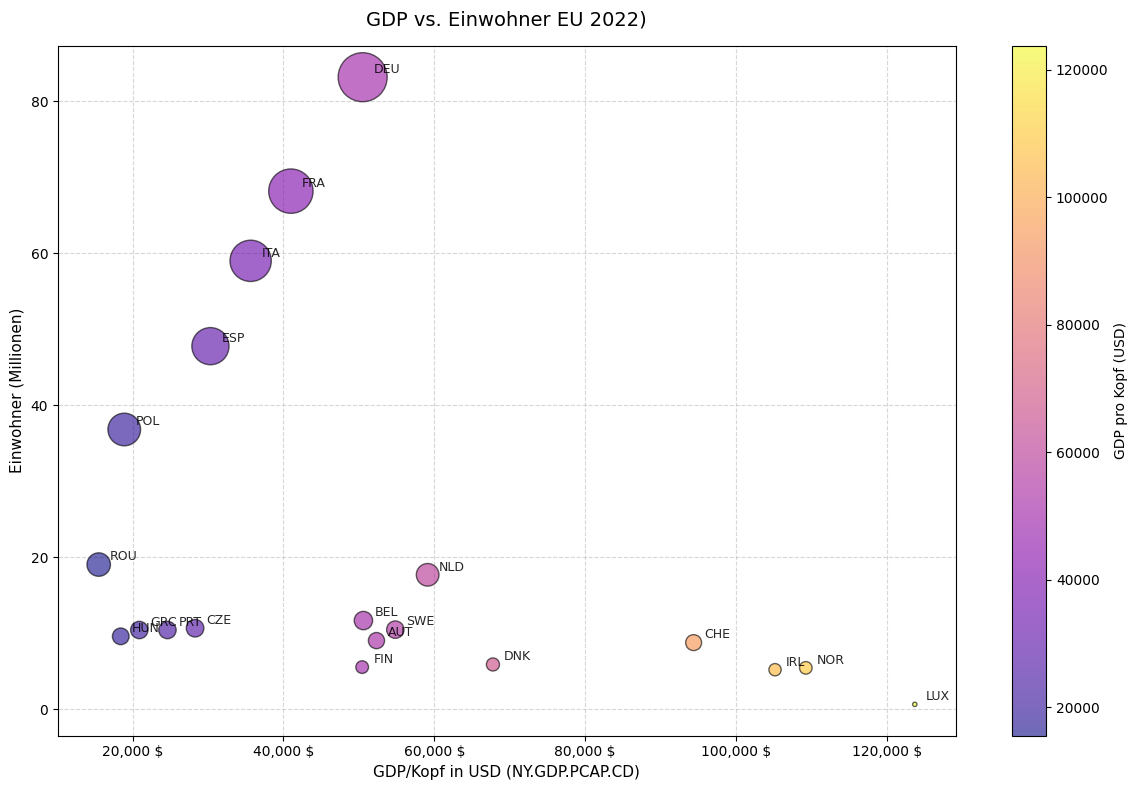

In [4]:
# 08-Matplotlib-exercice_08-3.py 18-06-26
# magic %matplotlib inline
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Echte CSV-Datei einlesen 
df = pd.read_csv("20Laender10Indikatoren.csv")

# 2. Liste der 20 europäischen Länder definieren
liste_der_20_laender = ["DEU", "FRA", "ITA", "ESP", "NLD","BEL", "SWE", "POL", "AUT", "CHE",
                        "DNK", "FIN", "NOR", "IRL", "PRT","GRC", "CZE", "HUN", "ROU", "LUX"]

# 3. Daten nach Jahr (2022) und Länderauswahl filtern
df_2022 = df[(df["year"] == 2022) & (df["iso3"].isin(liste_der_20_laender))].copy()

# Echte Daten live in Millionen umrechnen für die Y-Achse und die Punktgröße
pop_in_mio = df_2022["population"] / 1e6

# 4. Plot initialisieren
fig, ax = plt.subplots(figsize=(12, 8))

# 5. Scatter Plot erstellen
# x = BIP pro Kopf, y = Bevölkerung in Millionen
scatter = ax.scatter(
    df_2022["NY.GDP.PCAP.CD"],
    pop_in_mio,
    s=pop_in_mio * 15,            # Punktgröße prop. Einwohnerzahl
    alpha=0.6,
    c=df_2022["NY.GDP.PCAP.CD"],  # Farbverlauf koppelt an Wirtschaftskraft
    cmap="plasma",
    edgecolors="black",
    zorder=3
)

# 6. Ländernamen als Text-Labels neben den Punkten 
df_2022["country"] = df_2022["iso3"]
for i in range(len(df_2022)):
    ax.annotate(
        df_2022["country"].iloc[i], 
        (df_2022["NY.GDP.PCAP.CD"].iloc[i], pop_in_mio.iloc[i]),
        xytext=(8, 3), 
        textcoords="offset points", 
        fontsize=9,
        alpha=0.85
    )

# 7. Beschriftung und Styling
ax.set_title("GDP vs. Einwohner EU 2022)", fontsize=14, pad=15)
ax.set_xlabel("GDP/Kopf in USD (NY.GDP.PCAP.CD)", fontsize=11)
ax.set_ylabel("Einwohner (Millionen)", fontsize=11)

# Achsenbeschriftung für Tausender-Trennung und Dollar-Zeichen
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,} $".format(int(x))))

ax.grid(True, linestyle="--", alpha=0.5, zorder=1)

# Farbskala (Colorbar) hinzufügen
cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("GDP pro Kopf (USD)")

# 8. Diagramm anzeigen
plt.tight_layout()
plt.show()


**Exercise 9**
Using the population data from Exercise 3, compute the **correlation matrix** of the three countries' populations (hint: use `pivot` to reshape the DataFrame so that each country is a column, then use `np.corrcoef` or `df.corr()`). Display the result as a **heatmap**. Why are the correlations so high?

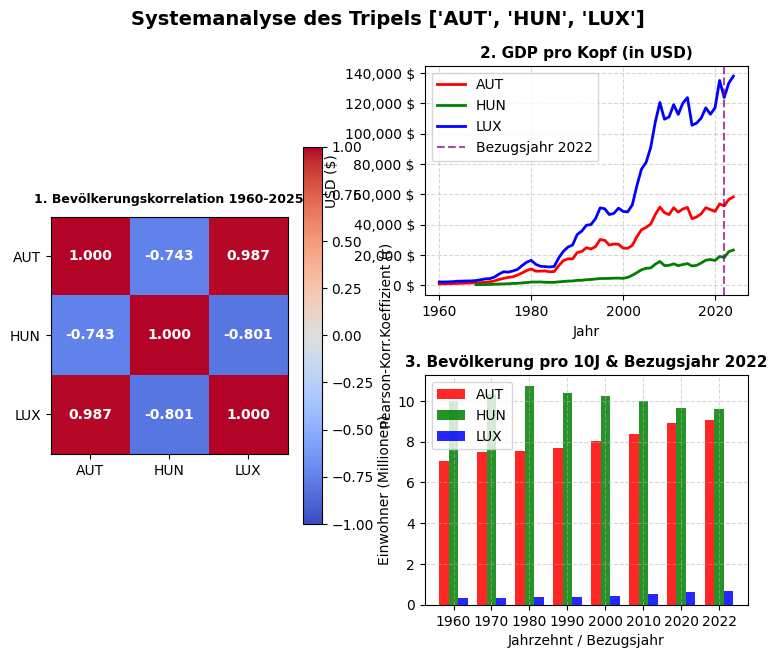

In [6]:
# 08-Matplotlib-exercice_09-3.py 18-06-26
# magic %matplotlib inline
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("20Laender10Indikatoren.csv")
tripel1 = ["DEU", "FRA", "ITA"]
tripel2 = ["AUT", "HUN", "LUX"]
tripel  = tripel2
df_tripel = df[df["iso3"].isin(tripel)].copy()

# Pivots für Bevölkerung und BIP pro Kopf ab 1960
df_pop_pivot = df_tripel.pivot(index="year", columns="iso3", values="population")
df_gdp_pivot = df_tripel.pivot(index="year", columns="iso3", values="NY.GDP.PCAP.CD")

# 3. Korrelationsmatrix für die Bevölkerung berechnen
corr_matrix = df_pop_pivot.corr()

# 4. Aggregation in 10-Jahres-Schritten für Bar-Chart (Bezugsjahr 2022)
jahrzehnte = [1960, 1970, 1980, 1990, 2000, 2010, 2020, 2022]
df_pop_decades = df_pop_pivot.loc[df_pop_pivot.index.isin(jahrzehnte)]
# Absolute Bevölkerung in Millionen umrechnen
df_pop_decades_mil = df_pop_decades / 1e6

# 5. Grafikfenster mit 3 Subplots initialisieren (1 links, 2 rechts gestapelt)
fig = plt.figure(figsize=(9, 7))
grid = fig.add_gridspec(2, 2, width_ratios=[1.1, 1.2], hspace=0.35, wspace=0.25)

ax_heat = fig.add_subplot(grid[:, 0]) # Linke Seite : Heatmap
ax_gdp = fig.add_subplot(grid[0, 1])  # Rechts oben : BIP
ax_bar = fig.add_subplot(grid[1, 1])  # Rechts unten: Bevölkerung

color1 = {"DEU": "red", "FRA": "green", "ITA": "blue"}
color2 = {"AUT": "red", "HUN": "green", "LUX": "blue"}
colors = color2

# --- SUBPLOT 1: HEATMAP (Bevölkerungskorrelation) ---
im = ax_heat.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax_heat.set_title("1. Bevölkerungskorrelation 1960-2025", fontsize=9, weight="bold", pad=10
)
ax_heat.set_xticks(np.arange(3))
ax_heat.set_yticks(np.arange(3))
ax_heat.set_xticklabels(tripel)
ax_heat.set_yticklabels(tripel)

for i in range(3):
    for j in range(3):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax_heat.text(
            j,
            i,
            f"{val:.3f}",
            ha="center",
            va="center",
            color=color,
            fontweight="bold",
        )

# Colorbar für die Heatmap einpassen
cbar = fig.colorbar(im, ax=ax_heat, shrink=0.7, pad=0.05)
cbar.set_label("Pearson-Korr.Koeffizient (r)")

# --- SUBPLOT 2: GDP / POPU BIP pro Kopf seit 1960) ---
for land in tripel:
    ax_gdp.plot(
        df_gdp_pivot.index,
        df_gdp_pivot[land],
        label=land,
        color=colors[land],
        linewidth=2,
    )
ax_gdp.axvline(
    2022, color="purple", linestyle="--", alpha=0.7, label="Bezugsjahr 2022"
)
ax_gdp.set_title(
    "2. GDP pro Kopf (in USD)", fontsize=11, weight="bold"
)
ax_gdp.set_xlabel("Jahr")
ax_gdp.set_ylabel("USD ($)")
ax_gdp.get_yaxis().set_major_formatter(
    plt.FuncFormatter(lambda x, loc: "{:,} $".format(int(x)))
)
ax_gdp.grid(True, linestyle="--", alpha=0.5)
ax_gdp.legend(loc="upper left")

# --- SUBPLOT 3: POPU / JAHRZEHNT (Grouped Bar Chart der Entwicklung) ---
labels = [f"{y}" for y in df_pop_decades_mil.index]
x = np.arange(len(labels))
width = 0.25

for i, land in enumerate(tripel):
    offset = (i - (len(tripel) - 1) / 2) * width
    ax_bar.bar(
        x + offset,
        df_pop_decades_mil[land],
        width,
        label=land,
        color=colors[land],
        alpha=0.85,
    )

ax_bar.set_title(
    "3. Bevölkerung pro 10J & Bezugsjahr 2022",
    fontsize=11,
    weight="bold",
)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels)
ax_bar.set_xlabel("Jahrzehnt / Bezugsjahr")
ax_bar.set_ylabel("Einwohner (Millionen)")
ax_bar.grid(True, linestyle="--", alpha=0.5)
ax_bar.legend(loc="upper left")

# --- GESAMTLAYOUT ---
plt.suptitle(
    f"Systemanalyse des Tripels {tripel}",
    fontsize=14,
    weight="bold",
    y=0.96,
)
plt.savefig("Tripel_2022.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Exercice 10 :Erzeuge einen Scree-Plot der die PCA für Merkmalen  mpg, cylinders, displacement, horsepower, weight, acceleration in der Auto.csv
# anzeigt.Er ermittelt : wieviel neue Variablen (Hauptkomponenten) brauchts mindestens, um die wichtigsten Informationen (Varianz) der Daten
# zusammenzufassen?. Die blauen Balken (Individual Variance) zeigen, wieviel Prozent Gesamtinformation des Datensatzes jede einzelne Hauptkomponente 
# (PC1 bis PC6) einfängt.PC1 (erster Balken) ist mit 86 % sehr hoch, weil Merkmale wie Gewicht, Hubraum (displ.), Zylinder und PS stark miteinander 
# korrelieren (schweres Auto <=> viele Zylinder, viel Hubraum, viel PS und viel Benzinverbrauch). PC1 fasst die Größen- und Leistungsdimension fast 
# vollständig zusammen. Dierote Linie (Cumulative Variance) addiert die Werte der Balken von links nach rechts auf und zeigt die Gesamtinformation.
# Nach PC2 liegt die Linie bei 94 % . D.h die Reduktion der 6 Daten-Dimensionen auf PC1,PC2 verliert weniger als 6% Information.
# Voraussetzung ist dabei, daß die Daten Z-NORMALISIERT SIND, also in jeder Spalte die Dimension verschwindet und "alle gleichbehandelt" werden ,in
# dem nur z-Werte frac{x-mu}\{sigma} miteinander verglichen werden.Dies besorgt der STANDART-SCALER per X = df[features],scaler = StandardScaler(),
# X_scaled = scaler.fit_transform(X) der im Modus GENERATE aufgerufen wird und den NORMALISIERTEN Datensatz Auto-normalized erzeugt.Dieser wird dann
# im Modus FAST_LOAD eingelesen.
# Fazit: der SCREE-Plot rechtfertigt einen PC1&PC2-Scatterplot (ax2) zu zeichnen, da PC1,PC2 fast die gesamte Information beschreiben, wobei Cluster 
# von sparsamen 4-Zylindern vs. schweren 8-Zylinder-Muscle-Cars sichtbar werden.
# 09_data-ex_04-5b_Loader.py 20-06-2026
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import TextBox
# =====================================================================
# MODUS-AUSWAHL
# "GENERATE"  : Lädt Auto.csv, normalisiert, formatiert und speichert.
# "FAST_LOAD" : Lädt direkt die perfekt geordnete Auto-normalized.csv.
# =====================================================================
MODE = "GENERATE" # "FAST_LOAD" 

features = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

if MODE == "GENERATE":
    print("Modus: Generiere normalisierte Daten...")
    # 1. Originaldaten laden und bereinigen
    df_original = pd.read_csv("Auto.csv")
    df_clean = df_original.replace('?', np.nan).dropna().reset_index(drop=True)
    
    # =====================================================================
    # NEUER DIENST: Erstellung der perfekt geordneten "Auto-tabloid.csv"
    # =====================================================================
    print("Formatiere Originaldaten zur 'Auto-tabloid.csv'...")
    df_tabloid = df_clean.copy()
    df_tabloid['name'] = df_tabloid['name'].str.split(' ').str[0]
    
    # ID-Spalte als erste Spalte hinzufügen und auf 3 Zeichen trimmen
    df_tabloid.insert(0, 'ID_Number', df_tabloid.index)
    df_tabloid['ID_Number']    = df_tabloid['ID_Number'].apply(lambda x: f"{x:3d}")
    
    # Spalten mit Ganzzahlen rechtsbündig ausrichten
    df_tabloid['cylinders']    = df_tabloid['cylinders'].apply(lambda x: f"{int(x):2d}")
    df_tabloid['displacement'] = df_tabloid['displacement'].apply(lambda x: f"{int(x):3d}")
    df_tabloid['horsepower']   = df_tabloid['horsepower'].apply(lambda x: f"{int(float(x)):3d}")
    df_tabloid['weight']       = df_tabloid['weight'].apply(lambda x: f"{int(x):4d}")
    df_tabloid['year']         = df_tabloid['year'].apply(lambda x: f"{int(x):2d}")
    df_tabloid['origin']       = df_tabloid['origin'].apply(lambda x: f"{int(x):1d}")
    
    # Fließkommazahlen mit Vorzeichen-Padding UND fester Gesamtbreite (5 Zeichen)
    df_tabloid['mpg']          = df_tabloid['mpg'].apply(lambda x: f"{x: 5.1f}")
    df_tabloid['acceleration'] = df_tabloid['acceleration'].apply(lambda x: f"{x: 5.1f}")
   
    
    # Speichern als Ersatz für die unordentliche Originaldatei
    df_tabloid.to_csv("Auto-tabloid.csv", index=False)
    print("Datei 'Auto-tabloid.csv' erfolgreich gespeichert.")
    # =====================================================================

    # [Hier folgt der restliche Code zur Berechnung der PCA-Normalisierung...]
    print("Modus: Generiere normalisierte Daten...")
    # 1. Originaldaten laden und bereinigen
    df_original = pd.read_csv("Auto.csv")
    df_clean = df_original.replace('?', np.nan).dropna().reset_index(drop=True)
    
    # 2. Datenmatrix X extrahieren und manuell standardisieren
    X = df_clean[features].astype(float).values
    X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    
    # Trimmen auf exakt 6 Nachkommastellen (Matrix-Ebene)
    X_scaled = np.round(X_scaled, 6)
    
    # 3. Normalisierte Daten in neuem DataFrame speichern
    df_norm = pd.DataFrame(X_scaled, columns=features)
    
    # Die ID-Spalte einfügen und strikt auf 3 Zeichen rechtsbündig trimmen
    df_norm.insert(0, 'ID_Number', df_clean.index) 
    df_norm['ID_Number'] = df_norm['ID_Number'].apply(lambda x: f"{x:3d}")
    
    df_norm['name'] = df_clean['name'] # Namen für Textbox erhalten
    
    # Als "Auto-normalized.csv" abspeichern
    # % .6f erzwingt das Vorzeichen-Leerzeichen-Padding für perfekte Spalten-Symmetrie
    df_norm.to_csv("Auto-normalized.csv", index=False, float_format="% .6f")
    print("Datei 'Auto-normalized.csv' erfolgreich mit maximaler Ordnung gespeichert.")
    
    df = df_norm

elif MODE == "FAST_LOAD":
    print("Modus: Schnelles Laden von 'Auto-normalized.csv'...")
    df = pd.read_csv("Auto-normalized.csv")
    X_scaled = df[features].values

else:
    raise ValueError("Ungültiger Modus! Wählen Sie 'GENERATE' oder 'FAST_LOAD'.")


# =====================================================================
# LINEARE ALGEBRA PIPELINE (Kovarianzmatrix & Eigendecomposition)
# =====================================================================
plt.rcParams['toolbar'] = 'None'

# Daten sind zentriert/skaliert: Sigma = (X_scaled^T * X_scaled) / (n - 1)
cov_matrix = np.cov(X_scaled, rowvar=False)

# Eigenvektoren und Eigenwerte extrahieren
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sortierung nach maximaler Varianz (absteigend)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Erklärte Varianz berechnen
variance_explained = eigenvalues / np.sum(eigenvalues)


# =====================================================================
# VISUALISIERUNG
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
# --- Barplot (Figure 1) ---
# fig1, ax1 = plt.subplots(figsize=(5.5, 4.20))
ax1.bar(range(1, 7), variance_explained, alpha=0.7, align='center', label='Individual Variance')
ax1.step(range(1, 7), np.cumsum(variance_explained), where='mid', label='Cumulative Variance', color='red')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component Index')
ax1.legend(loc='best')
ax1.set_title('Screen Plot: Captured Information')


# --- Interactive PCA Scatter Plot (Figure 2) ---
# Projektion der normalisierten Daten auf die ersten beiden Hauptkomponenten
PC1 = X_scaled @ eigenvectors[:, 0]
PC2 = X_scaled @ eigenvectors[:, 1]

# fig2, ax2 = plt.subplots(figsize=(7, 6))
plt.subplots_adjust(bottom=0.2) # Platz für die Textbox

# ---------------------------------------------------------------------
# INTEGRATION: Mathematisches Fadenkreuz (Crosshair bei PC1=0 und PC2=0)
# ---------------------------------------------------------------------
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
# ---------------------------------------------------------------------

# Scatter Plot aller Datenpunkte
scatter = ax2.scatter(PC1, PC2, alpha=0.6, color='blue', label='Data Points')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_title('PCA Scatter Plot (Enter Number to Highlight)')

# Nummerierung neben den Punkten einblenden
for i in range(len(PC1)):
    ax2.text(PC1[i] + 0.05, PC2[i] + 0.05, str(int(df['ID_Number'].iloc[i])), fontsize=8, alpha=0.4)

# Platzhalter für den roten Highlight-Punkt
highlighted_dot, = ax2.plot([], [], 'ro', markersize=10, label='Selected Point')
ax2.legend(loc='best')

# Positionierung der TextBox am unteren Rand
ax_box = plt.axes([0.7, 0.05, 0.04, 0.04])
max_idx = int(df['ID_Number'].max())
text_box = TextBox(ax_box, f'Enter ID (0 to {max_idx}): ', initial="")

# Callback-Funktion für die Textbox (mit Leerzeichen-Berücksichtigung)
def submit(text):
    try:
        val = int(text)
        # astype(int) ignoriert führende Leerzeichen im ID
        matching_rows = df[df['ID_Number'].astype(int) == val]
        
        if not matching_rows.empty:
            row_idx = matching_rows.index[0] # Ersten passenden Index greifen
            # Roten Punkt auf die projizierten PC-Koordinaten setzen
            highlighted_dot.set_data([PC1[row_idx]], [PC2[row_idx]])
            
            car_name = df['name'].iloc[row_idx]
            ax2.set_title(f'ID {val}: {car_name}')
            fig2.canvas.draw_idle()
        else:
            ax2.set_title("ID nicht gefunden!")
            highlighted_dot.set_data([], [])
            fig2.canvas.draw_idle()
    except ValueError:
        ax2.set_title("Bitte eine gültige Ganzzahl eingeben!")
        highlighted_dot.set_data([], [])
        fig2.canvas.draw_idle()

text_box.on_submit(submit)
plt.show()


Modus: Generiere normalisierte Daten...
Formatiere Originaldaten zur 'Auto-tabloid.csv'...
Datei 'Auto-tabloid.csv' erfolgreich gespeichert.
Modus: Generiere normalisierte Daten...
Datei 'Auto-normalized.csv' erfolgreich mit maximaler Ordnung gespeichert.


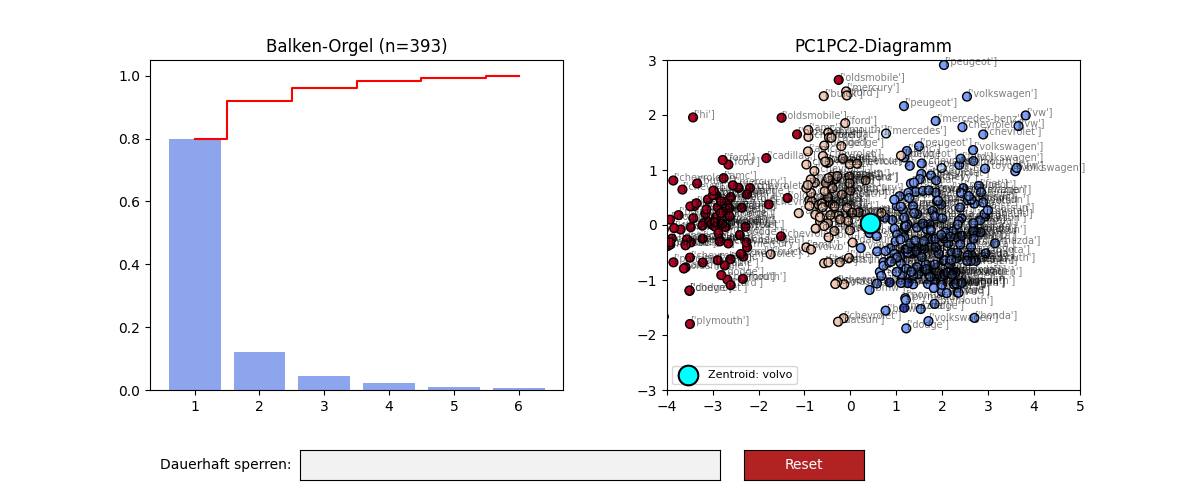

In [2]:
# 09_data-ex_11_ScreeLoad_03.py 22-06-2026
import matplotlib.pyplot as plt
from matplotlib.widgets import TextBox, Button
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from io import StringIO

# --- 1. Die Grundgesamtheit ---
# df_original = pd.read_csv("Auto.csv")
# 1. Datei einlesen: Wir sagen Pandas, dass '?' ein fehlender Wert (NaN) ist.
# Falls deine CSV Leerzeichen statt Kommas hat, nutze: sep=r'\s+' statt standardmäßig Komma
df_original = pd.read_csv('Auto-tabloid.csv', na_values='?')

# 2. Zeilen mit fehlenden Werten (wie beim Pinto) gnadenlos rausschmeißen
df_original = df_original.dropna(subset=['horsepower']).copy()

# 3. Sicherstellen, dass horsepower jetzt wirklich als echte Zahl (float) im Raum steht
df_original['horsepower'] = df_original['horsepower'].astype(float)

feats = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
df = df_original.copy()
df['name'] = df['name'].str.split(' ').str[0]

# --- 2. GUI & Layout ---
%matplotlib widget
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plt.subplots_adjust(bottom=0.22, wspace=0.25)

is_drawing = False

def update():
    global is_drawing
    if is_drawing or len(df) < 3: return
    is_drawing = True
    ax1.clear(); ax2.clear()
    
    # PCA-Berechnung auf dem verbliebenen Rumpf-Datensatz
    X = StandardScaler().fit_transform(df[feats])
    vals, vecs = np.linalg.eig(np.cov(X, rowvar=False))
    idx = np.argsort(vals)[::-1]
    vals, vecs = vals[idx], vecs[:, idx]
    
    # Links: Die SCREE-Balken der Lambdas
    ax1.bar(range(1, 7), vals/sum(vals), alpha=0.6, color='royalblue')
    ax1.step(range(1, 7), np.cumsum(vals/sum(vals)), where='mid', color='red')
    ax1.set_title(f"Balken-Orgel (n={len(df)})"); ax1.set_ylim(0, 1.05)
    
    # Rechts: Projektion
    p1, p2 = X @ vecs[:, 0], X @ vecs[:, 1]
    coords = np.column_stack((p1, p2))
    
    ax2.scatter(p1, p2, c=df['cylinders'], cmap='coolwarm', edgecolors='k', s=40, zorder=2)
    ax2.set_title("PC1PC2-Diagramm")
    
    # WICHTIG: Achsen festfrieren, damit man das Wandern sieht!
    ax2.set_xlim(-4, 5)
    ax2.set_ylim(-3, 3)
    
    for i, txt in enumerate(df['name']):
        ax2.annotate(txt.split()[:2], (p1[i], p2[i]), fontsize=7, alpha=0.5)
        
    # Medoid-Suchschleife nach deinem Ansatz
    min_mean_dist = float('inf')
    best_idx = 0
    for i in range(len(coords)):
        dists = np.sqrt(np.sum((coords - coords[i])**2, axis=1))
        if np.mean(dists) < min_mean_dist:
            min_mean_dist = np.mean(dists)
            best_idx = i
            
    # Zentroid-Blob einzeichnen
    ax2.scatter(coords[best_idx, 0], coords[best_idx, 1], 
               color='aqua', edgecolor='black', linewidth=1.5, s=200, 
               label=f"Zentroid: {' '.join(df.iloc[best_idx]['name'].split()[:2])}", zorder=3)
    ax2.legend(loc='lower left', fontsize=8)
    
    is_drawing = False
    fig.canvas.draw_idle()

# --- 3. Interaktive Steuerung ---
tx_box = plt.axes([0.25, 0.04, 0.35, 0.06])
re_box = plt.axes([0.62, 0.04, 0.10, 0.06])

box = TextBox(tx_box, 'Dauerhaft sperren: ', initial='')
btn = Button(re_box, 'Reset', color='firebrick', hovercolor='red')
btn.label.set_color('white')

def on_submit(text):
    global df
    if text.strip():
        df = df[~df['name'].str.contains(text, case=False, na=False)].copy()
        box.set_val('')
        update()

def on_reset(event):
    global df
    df = df_original.copy()
    box.set_val('')
    update()

box.on_submit(on_submit)
btn.on_clicked(on_reset)

update()
plt.show()
